In [2]:
import pandas as pd

df = pd.read_csv("../dataset/online_food_delivery_synthetic_dataset.csv")

In [22]:
df.head()

,Order_ID,Order_Date,Customer_ID,City,Restaurant,Food_Category,Quantity,Price,Discount,Delivery_Fee,Payment_Method,Order_Status,Rating,Total_Amount,Total_Sales
0,ORD00833,2025-01-01,CUST0085,Mumbai,Bombay Bites,Chinese,1,296.52,42.42,40,Debit Card,Cancelled,3.6,294.10,296.52
1,ORD00324,2025-01-01,CUST0112,Chennai,Chennai Bites,Chinese,1,276.98,31.58,20,Credit Card,Delivered,3.8,265.40,276.98
2,ORD00528,2025-01-01,CUST0734,Pune,Deccan Kitchen,Chinese,2,319.65,44.24,20,Credit Card,Delivered,3.8,615.06,639.30
3,ORD02437,2025-01-01,CUST0167,Pune,Deccan Kitchen,Healthy Food,2,259.21,30.53,60,UPI,Delivered,4.5,547.89,518.42
4,ORD01444,2025-01-01,CUST0146,Chennai,Spice Hub,Pizza,1,454.31,46.88,40,Credit Card,Delivered,4.8,447.43,454.31


In [23]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 3010 entries, 0 to 3009
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order_ID        3010 non-null   str           
 1   Order_Date      3010 non-null   datetime64[us]
 2   Customer_ID     3010 non-null   str           
 3   City            3010 non-null   str           
 4   Restaurant      3010 non-null   str           
 5   Food_Category   3010 non-null   str           
 6   Quantity        3010 non-null   int64         
 7   Price           3010 non-null   float64       
 8   Discount        3010 non-null   float64       
 9   Delivery_Fee    3010 non-null   int64         
 10  Payment_Method  2985 non-null   str           
 11  Order_Status    3010 non-null   str           
 12  Rating          2949 non-null   float64       
 13  Total_Amount    3010 non-null   float64       
 14  Total_Sales     3010 non-null   float64       
dtypes: datetime64[u

,Order_Date,Quantity,Price,Discount,Delivery_Fee,Rating,Total_Amount,Total_Sales
count,3010,3010.000000,3010.000000,3010.000000,3010.000000,2949.000000,3010.000000,3010.000000
mean,2025-07-03 01:11:16.943521,1.612625,261.251618,42.455123,34.508306,4.090268,412.451814,420.398631
min,2025-01-01 00:00:00,1.000000,63.680000,0.020000,20.000000,2.100000,95.690000,70.390000
25%,2025-04-04 00:00:00,1.000000,196.410000,15.832500,20.000000,3.700000,249.120000,241.262500
50%,2025-07-02 00:00:00,1.000000,256.395000,31.395000,30.000000,4.100000,338.105000,337.285000
75%,2025-10-02 00:00:00,2.000000,318.982500,55.592500,40.000000,4.500000,520.012500,534.770000
max,2025-12-31 00:00:00,4.000000,570.200000,250.000000,60.000000,5.000000,1890.960000,1931.000000
std,NaN,0.823452,82.026271,38.968215,11.634775,0.529737,234.966255,259.637386


In [24]:
df.isnull().sum()

Order_ID           0
Order_Date         0
Customer_ID        0
City               0
Restaurant         0
Food_Category      0
Quantity           0
Price              0
Discount           0
Delivery_Fee       0
Payment_Method    25
Order_Status       0
Rating            61
Total_Amount       0
Total_Sales        0
dtype: int64

In [25]:
df.isnull().sum()

Order_ID           0
Order_Date         0
Customer_ID        0
City               0
Restaurant         0
Food_Category      0
Quantity           0
Price              0
Discount           0
Delivery_Fee       0
Payment_Method    25
Order_Status       0
Rating            61
Total_Amount       0
Total_Sales        0
dtype: int64

In [26]:
df.duplicated().sum()

np.int64(10)

In [27]:
df = df.drop_duplicates()

In [30]:
df.duplicated().sum()

np.int64(0)

In [29]:
df[df['Quantity'] <= 0]

,Order_ID,Order_Date,Customer_ID,City,Restaurant,Food_Category,Quantity,Price,Discount,Delivery_Fee,Payment_Method,Order_Status,Rating,Total_Amount,Total_Sales


In [31]:
df[df['Price'] < 0]

,Order_ID,Order_Date,Customer_ID,City,Restaurant,Food_Category,Quantity,Price,Discount,Delivery_Fee,Payment_Method,Order_Status,Rating,Total_Amount,Total_Sales


In [32]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

In [9]:
df['Total_Sales'] = df['Quantity'] * df['Price']

In [33]:
df['Total_Sales'].sum()

np.float64(1260660.2999999998)

In [16]:
df['Order_ID'].nunique()

3000

In [34]:
df['Total_Sales'].mean()

np.float64(420.22009999999995)

In [35]:
df.groupby('City')['Total_Sales'].sum()

City
Bengaluru    192230.56
Chennai      181518.46
Delhi        186489.08
Hyderabad    167831.44
Kochi        118807.12
Kolkata      107843.03
Mumbai       182180.55
Pune         123760.06
Name: Total_Sales, dtype: float64

In [36]:
df.groupby('Food_Category')['Total_Sales'].sum()

Food_Category
Biryani         233481.05
Burgers         118602.92
Chinese         178810.68
Desserts         57936.77
Healthy Food    100970.00
North Indian    193814.39
Pizza           240752.94
South Indian    136291.55
Name: Total_Sales, dtype: float64

In [37]:
df.groupby('Restaurant')['Total_Sales'].sum()

Restaurant
Bengal Feast       30503.76
Bengaluru Bowl     51174.29
Biryani Corner     28885.21
Biryani Point      37088.32
Bombay Bites       41708.91
Cafe Central       29203.34
Capital Bites      45131.96
Chennai Bites      44388.02
Coastal Kitchen    42198.80
Coastal Treats     27161.56
Coconut Cafe       36367.68
Deccan Delights    44144.27
Deccan Kitchen     28369.09
Delhi Zaika        54956.28
Dosa House         46483.12
East Spice         26470.61
Garden Kitchen     40181.34
Hyderabad House    43606.36
Kerala Kitchen     24102.87
Kolkata Kitchen    21983.45
Malabar Bites      31175.01
Marathi Meals      32500.41
Mumbai Masala      53075.82
Nawab Kitchen      42992.49
Pune Pantry        33687.22
Punjabi Rasoi      48959.94
South Spice        53960.86
Spice Hub          43429.49
Street Feast       37440.90
Tandoor Tales      45197.02
Tech Tadka         46914.07
Urban Tiffin       47217.83
Name: Total_Sales, dtype: float64

In [38]:
df.groupby(
    df['Order_Date'].dt.to_period('M')
)['Total_Sales'].sum()

Order_Date
2025-01     98055.77
2025-02     97474.63
2025-03    101538.68
2025-04    111360.26
2025-05    112987.40
2025-06    108291.73
2025-07    109994.82
2025-08    103193.54
2025-09    105275.77
2025-10     99164.35
2025-11    104537.90
2025-12    108785.45
Freq: M, Name: Total_Sales, dtype: float64

In [39]:
df.select_dtypes(include='number').corr()

,Quantity,Price,Discount,Delivery_Fee,Rating,Total_Amount,Total_Sales
Quantity,1.000000,-0.013901,0.563858,0.019859,0.005219,0.811266,0.817891
Price,-0.013901,1.000000,0.328938,-0.010268,-0.003910,0.496931,0.499524
Discount,0.563858,0.328938,1.000000,-0.011403,0.015507,0.593511,0.687720
Delivery_Fee,0.019859,-0.010268,-0.011403,1.000000,-0.001732,0.059660,0.007503
Rating,0.005219,-0.003910,0.015507,-0.001732,1.000000,0.008015,0.009672
Total_Amount,0.811266,0.496931,0.593511,0.059660,0.008015,1.000000,0.991349
Total_Sales,0.817891,0.499524,0.687720,0.007503,0.009672,0.991349,1.000000


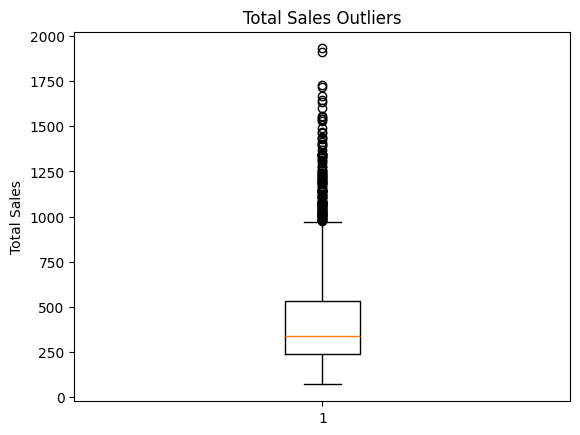

In [40]:
import matplotlib.pyplot as plt

plt.boxplot(df['Total_Sales'])
plt.title('Total Sales Outliers')
plt.ylabel('Total Sales')
plt.show()

In [4]:
# Final dataset check

print("Final dataset shape:", df.shape)
print("Total rows:", len(df))
print("Total columns:", len(df.columns))

Final dataset shape: (3010, 14)
Total rows: 3010
Total columns: 14


In [5]:
df['Order_Status'].value_counts()

Order_Status
Delivered    2646
Cancelled     277
Returned       87
Name: count, dtype: int64

In [6]:
df['Payment_Method'].value_counts()

Payment_Method
UPI            1399
Credit Card     589
Debit Card      509
Wallet          252
Cash            236
Name: count, dtype: int64

In [7]:
df['Rating'].describe()

count    2949.000000
mean        4.090268
std         0.529737
min         2.100000
25%         3.700000
50%         4.100000
75%         4.500000
max         5.000000
Name: Rating, dtype: float64

In [10]:
city_sales = df.groupby('City')['Total_Sales'].sum().sort_values(ascending=False)

city_sales

City
Bengaluru    193049.59
Delhi        188413.72
Mumbai       182560.12
Chennai      182086.06
Hyderabad    167831.44
Pune         124143.32
Kochi        119159.54
Kolkata      108156.09
Name: Total_Sales, dtype: float64

In [11]:
city_sales.head(3)

City
Bengaluru    193049.59
Delhi        188413.72
Mumbai       182560.12
Name: Total_Sales, dtype: float64

In [12]:
category_sales = df.groupby('Food_Category')['Total_Sales'].sum().sort_values(ascending=False)

category_sales

Food_Category
Pizza           241503.84
Biryani         235547.54
North Indian    194633.42
Chinese         179084.36
South Indian    136291.55
Burgers         118602.92
Healthy Food    101134.00
Desserts         58602.25
Name: Total_Sales, dtype: float64

In [13]:
category_sales.head(3)

Food_Category
Pizza           241503.84
Biryani         235547.54
North Indian    194633.42
Name: Total_Sales, dtype: float64

In [14]:
restaurant_sales = df.groupby('Restaurant')['Total_Sales'].sum().sort_values(ascending=False)

restaurant_sales.head(5)

Restaurant
Delhi Zaika       56607.24
South Spice       54779.89
Mumbai Masala     53455.39
Bengaluru Bowl    51174.29
Punjabi Rasoi     48959.94
Name: Total_Sales, dtype: float64

In [19]:
monthly_sales = df.groupby(
    df['Order_Date'].dt.to_period('M')
)['Total_Sales'].sum()

monthly_sales

Order_Date
2025-01     98055.77
2025-02     98499.21
2025-03    101538.68
2025-04    111360.26
2025-05    113770.57
2025-06    108674.99
2025-07    109994.82
2025-08    104325.63
2025-09    106175.83
2025-10     99164.35
2025-11    105054.32
2025-12    108785.45
Freq: M, Name: Total_Sales, dtype: float64

In [20]:
monthly_sales.idxmax(), monthly_sales.max()

(Period('2025-05', 'M'), np.float64(113770.57))

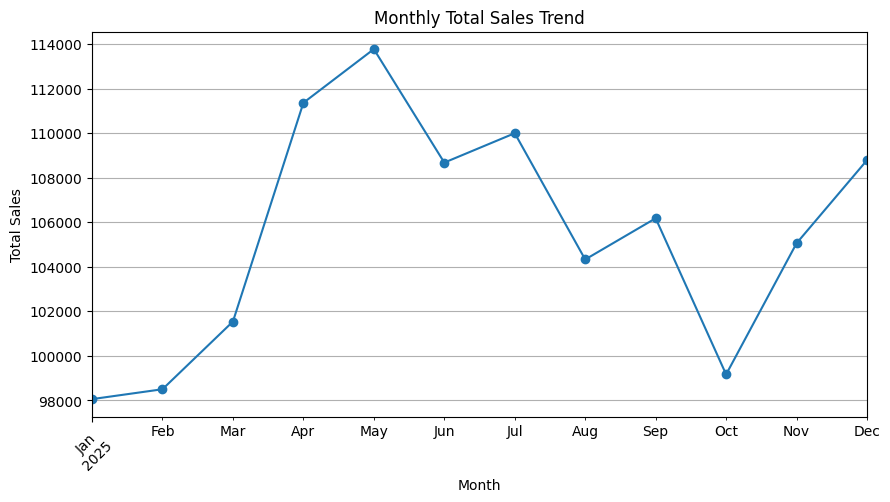

In [41]:
monthly_sales.plot(kind='line', marker='o', figsize=(10,5))

plt.title('Monthly Total Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## EDA Findings

1. Bengaluru generated the highest total sales among all cities.
2. Pizza was the highest-performing food category by total sales.
3. May recorded the highest monthly sales during 2025.
4. Quantity has a strong positive relationship with Total Sales.
5. Total Amount has a very strong positive relationship with Total Sales.
6. Delivery Fee has a very weak relationship with Total Sales.
7. Rating has very little correlation with Total Sales.
8. Duplicate records were identified and removed during data cleaning.
9. Missing values in Payment Method and Rating were handled appropriately.
10. The boxplot was used to identify potential high-value sales outliers.